<h1>SOLAR PROJECT<h1?

In [69]:
#imports
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')
print("Libraries imported successfully. Ready to work")

Libraries imported successfully. Ready to work


In [70]:
#loading data
generation_1=pd.read_csv('../data/Plant_1_Generation_Data.csv')
weather_1= pd.read_csv('../data/Plant_1_Weather_Sensor_Data.csv')

print("Data loaded into DataFrames.")

Data loaded into DataFrames.


In [71]:
generation_1.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [72]:
weather_1.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [73]:
generation_1.info()
weather_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   floa

In [74]:
#Convert the date_time column from strings(objects) to datetime object
generation_1['DATE_TIME']=pd.to_datetime(generation_1['DATE_TIME'], dayfirst=True)
weather_1['DATE_TIME']=pd.to_datetime(weather_1['DATE_TIME'], dayfirst=True)
generation_1.info()
weather_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  object        
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 3.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[ns]
 1   PLANT_ID             3182 non-null   int64         
 2   SOURCE_KEY           3182 non-n

In [75]:
#finding unique inverters
num_inverters= generation_1['SOURCE_KEY'].nunique()
print(f"Total numbers of inverters: {num_inverters}")

Total numbers of inverters: 22


In [76]:
#finding the first and last timestamps in our generation data
start_time=generation_1['DATE_TIME'].min()
end_time=generation_1['DATE_TIME'].max()
print(f"plant 1 data starts on: {start_time} and ends on: {end_time}")

plant 1 data starts on: 2020-05-15 00:00:00 and ends on: 2020-06-17 23:45:00


In [77]:
#finding the first and last timestamps in our weather data
start_time1=weather_1['DATE_TIME'].min()
end_time1=weather_1['DATE_TIME'].max()
print(f"plant 1 data starts on: {start_time1} and ends on: {end_time1}")

plant 1 data starts on: 2020-05-15 00:00:00 and ends on: 2020-06-17 23:45:00


In [83]:
#merging data-inner
plant_1_merged=pd.merge(generation_1, weather_1, on=['DATE_TIME','PLANT_ID'],how='inner')
plant_1_merged.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [79]:
#creatng a new column called efficiency which wwill tell us how much % dc power is converted to ac
plant_1_merged['EFFICIENCY']=(plant_1_merged['AC_POWER']/ plant_1_merged['DC_POWER']*100)
plant_1_merged['EFFICIENCY'].describe()
                              

count    36823.000000
mean         9.771885
std          0.045834
min          9.555185
25%          9.757890
50%          9.784509
75%          9.801443
max         10.659219
Name: EFFICIENCY, dtype: float64

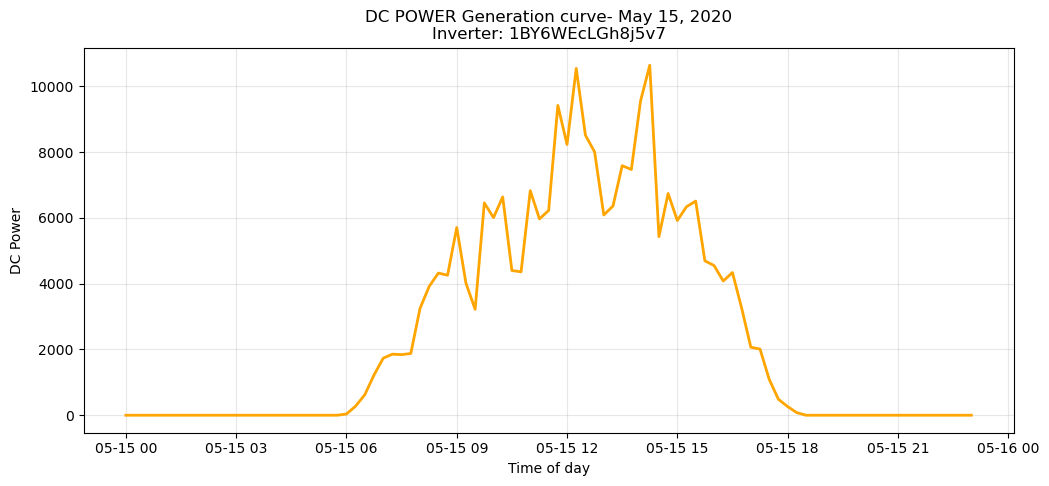

In [87]:
import matplotlib.pyplot as plt
single_inverter= plant_1_merged['SOURCE_KEY_x'].iloc[0]
mask= (plant_1_merged['DATE_TIME'].dt.date== pd.to_datetime('2020-05-15').date()) & (plant_1_merged['SOURCE_KEY_x']== single_inverter)
day_data= plant_1_merged[mask]


plt.figure(figsize=(12, 5))
plt.plot(day_data['DATE_TIME'], day_data['DC_POWER'], color='orange',linewidth=2)
plt.title(f'DC POWER Generation curve- May 15, 2020\nInverter: {single_inverter}')
plt.xlabel('Time of day')
plt.ylabel('DC Power')
plt.grid(True, alpha=0.3)
plt.show()

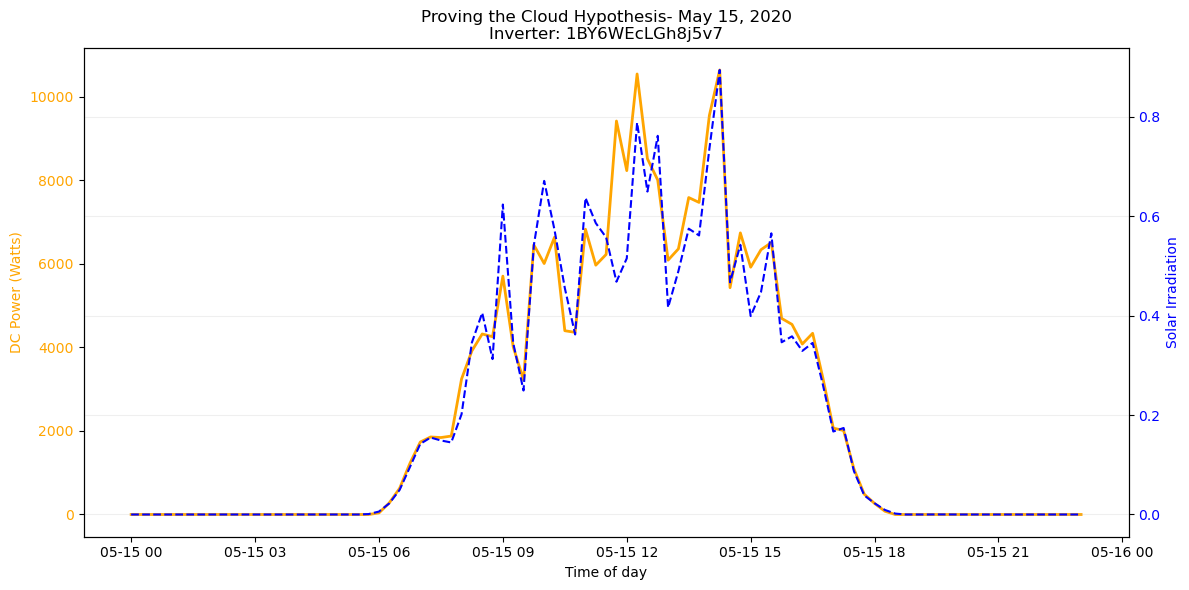

In [89]:
fig, ax1= plt.subplots(figsize=(12,6))
color='orange'
ax1.set_xlabel('Time of day')
ax1.set_ylabel('DC Power (Watts)', color=color)
ax1.plot(day_data['DATE_TIME'], day_data['DC_POWER'], color=color, linewidth=2,label='DC Power')
ax1.tick_params(axis='y', labelcolor=color)

ax2=ax1.twinx()

color='blue'
ax2.set_ylabel('Solar Irradiation',color=color)
ax2.plot(day_data['DATE_TIME'], day_data['IRRADIATION'], color=color, linewidth=1.5, linestyle='--',label='Irradiation')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Proving the Cloud Hypothesis- May 15, 2020\nInverter: {single_inverter}')
fig.tight_layout()
plt.grid(True, alpha=0.2)
plt.show()

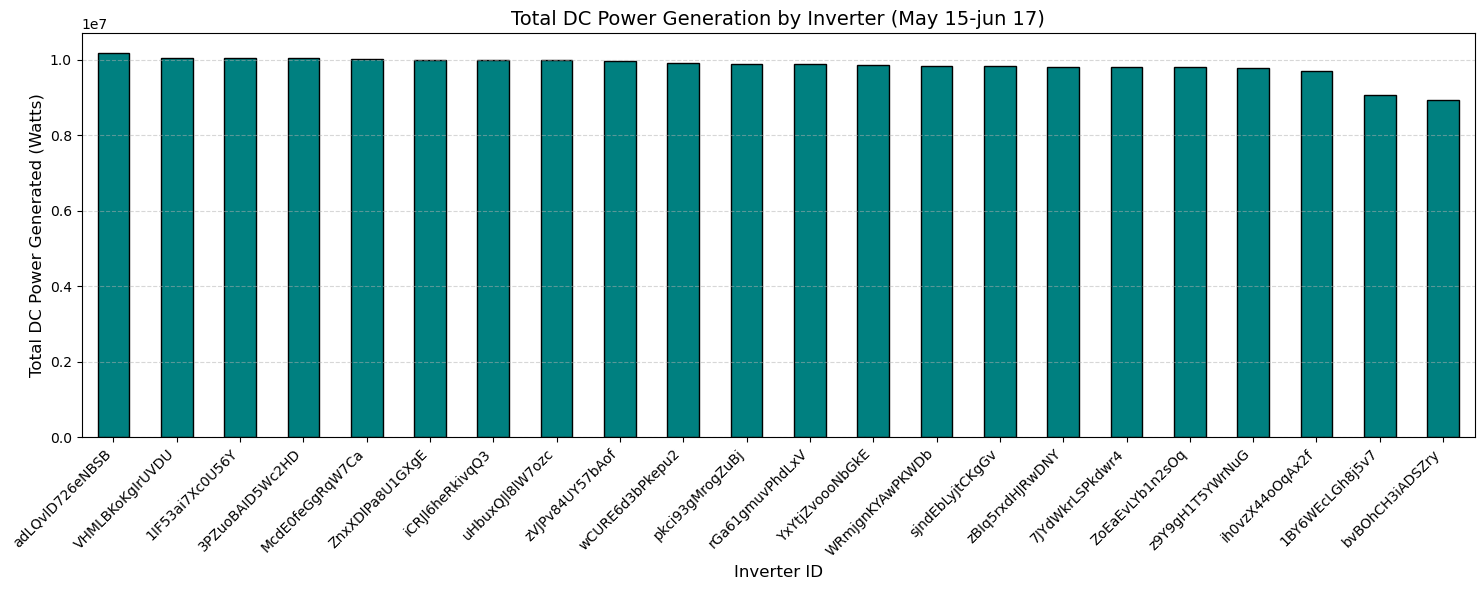

In [98]:
inverter_totals= plant_1_merged.groupby('SOURCE_KEY_x')['DC_POWER'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,6))
inverter_totals.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Total DC Power Generation by Inverter (May 15-jun 17)', fontsize=14)
plt.xlabel('Inverter ID', fontsize=12)
plt.ylabel('Total DC Power Generated (Watts)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

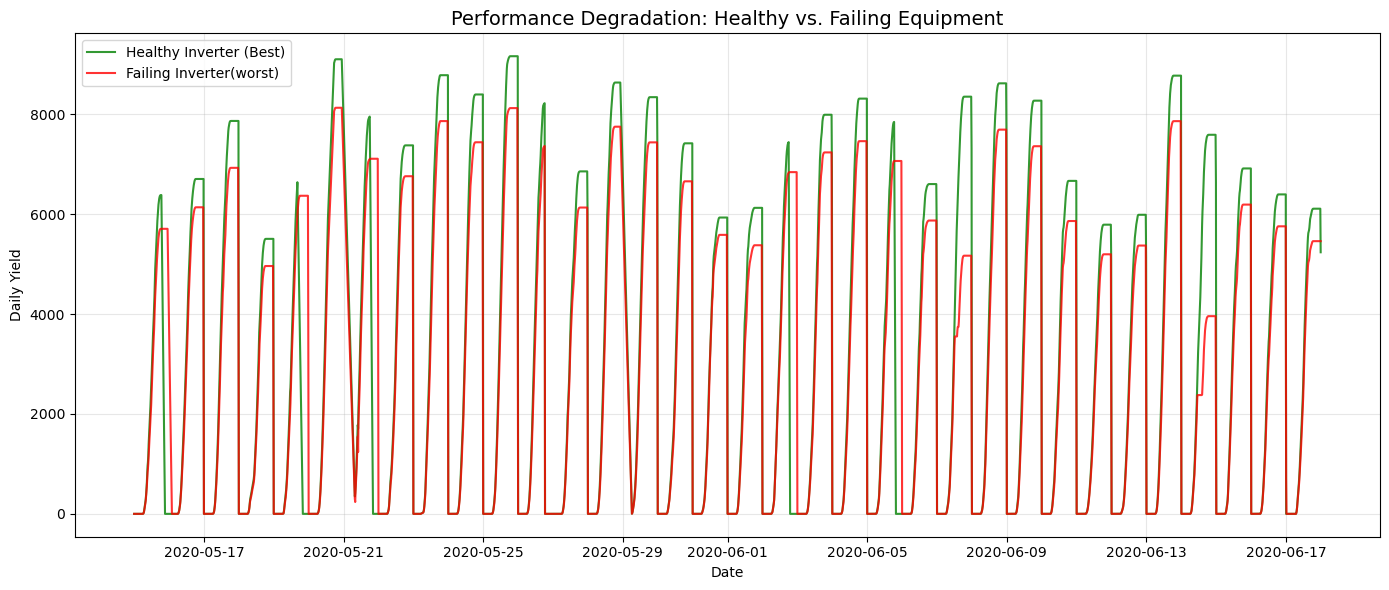

In [101]:
#comparing the besta and the worst inverters
best_inverter='adLQvlD726eNBSB'
worst_inverter = 'bvBOhCH3iADSZry'

best_data= plant_1_merged[plant_1_merged['SOURCE_KEY_x']==best_inverter]
worst_data= plant_1_merged[plant_1_merged['SOURCE_KEY_x']==worst_inverter]

plt.figure(figsize=(14,6))
plt.plot(best_data['DATE_TIME'], best_data['DAILY_YIELD'], color='green', label='Healthy Inverter (Best)', alpha=0.8)
plt.plot(worst_data['DATE_TIME'], worst_data['DAILY_YIELD'], color='red', label= 'Failing Inverter(worst)', alpha=0.8)

plt.title('Performance Degradation: Healthy vs. Failing Equipment', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Yield')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()